In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('whitegrid', rc={'ytick.left': True, 'ytick.color': 'silver'})
plt.rcParams['axes.autolimit_mode'] = 'round_numbers'
plt.rcParams['ytick.labelcolor'] = 'black'
sns.set_palette('colorblind')

In [3]:
df = pd.read_csv('govsites.csv')

In [4]:
df['sort'] = df.groupby('url')['package-0'].transform('mean')
df = df.sort_values(by='sort', ascending=False).drop('sort', axis=1).reset_index(drop=True)

In [5]:
df_mean = df.groupby('url').mean()
df_mean.describe()

,transferSize,decodedBodySize,resourceCount,scriptCount,imageCount,divCount,runtime,package-0,package-0-core,package-0-uncore
count,1116.000000,1.116000e+03,1116.000000,1116.000000,1116.000000,1116.000000,1116.000000,1116.000000,1116.000000,1116.000000
mean,28449.903076,1.112788e+05,38.634558,21.504182,11.549731,136.501643,4.481920,2.482035,0.946497,0.000063
std,36629.793039,1.118505e+05,26.310716,17.461898,16.612006,153.783545,1.341092,2.266954,1.201150,0.000028
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,4.023718,0.145987,0.014658,0.000000
25%,9941.750000,3.911675e+04,23.000000,9.000000,4.000000,65.000000,4.160019,1.098657,0.325638,0.000049
50%,20762.500000,8.532850e+04,35.000000,18.000000,8.000000,106.000000,4.288728,2.005965,0.589010,0.000061
75%,37066.000000,1.641882e+05,53.000000,29.000000,14.000000,168.000000,4.500285,3.018202,1.116935,0.000073
max,491638.000000,1.570611e+06,220.000000,140.000000,327.000000,2146.000000,34.291749,23.084760,15.097513,0.000525


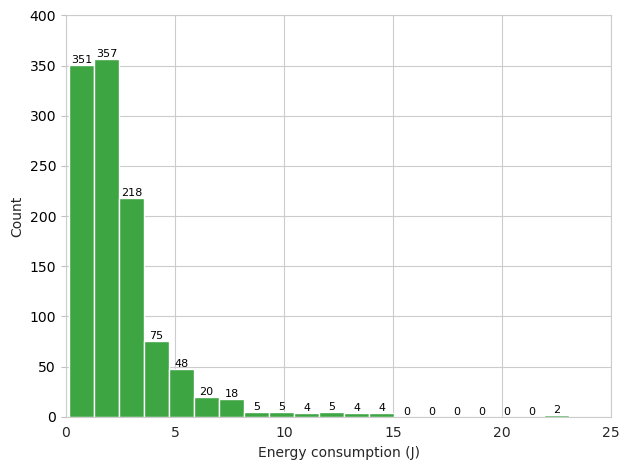

In [6]:
ax = sns.histplot(df_mean, x='package-0', bins=20, color='#3DA542', alpha=1)

c = ax.containers[0]
bins = [rect.get_height() for rect in c]
ax.bar_label(c, color='k', fontsize=8)

plt.xlim(0,None)
plt.xlabel('Energy consumption (J)')
plt.tight_layout()
plt.show()

In [7]:
def squash(s):
    ''' Replace everthing between outermost `/` with dots. '''
    import re
    return re.sub(r'(?<=/).*(?=/)', '...', s) if s.count('/') >= 2 else s

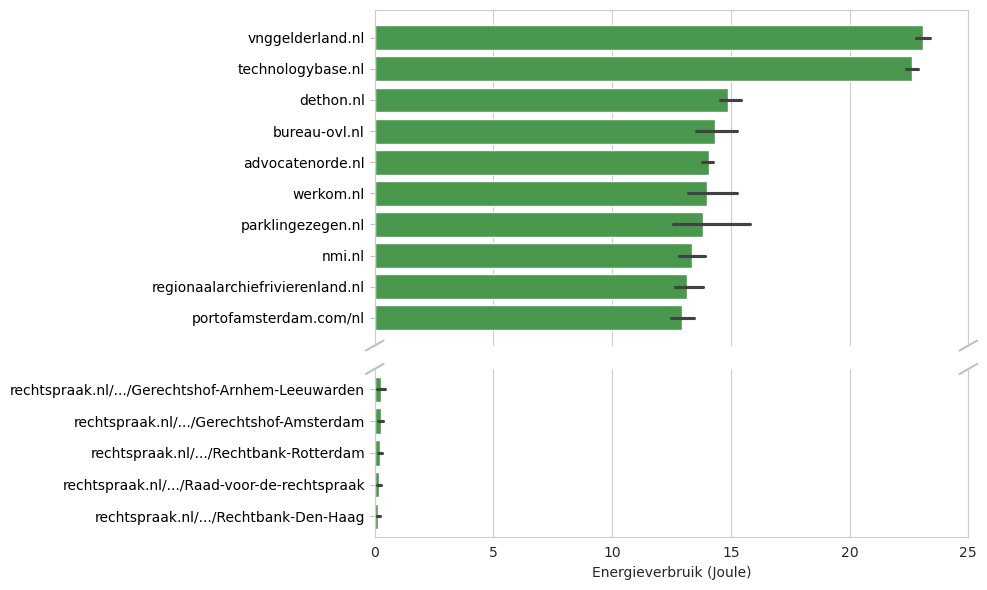

In [8]:
N_TOP, N_BOT = 10, 5
ASPECT = N_TOP / N_BOT
top, bot = df[:(5*N_TOP)], df[-(5*N_BOT):]

fig, (ax0, ax1) = plt.subplots(2, sharex=True, height_ratios=[N_TOP,N_BOT], figsize=(10,6))
sns.barplot(y=list(map(squash, top['url'])), x=top['package-0'], orient='h', color='#3DA542', ax=ax0)
sns.barplot(y=list(map(squash, bot['url'])), x=bot['package-0'], orient='h', color='#3DA542', ax=ax1)
ax1.set_xlabel('Energieverbruik (Joule)')

# Hide spines between axes
ax0.spines['bottom'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Add diagonal break marks
d = .015
kwargs = dict(transform=ax0.transAxes, color='silver', clip_on=False)
ax0.plot((0-d, 0+d), (0-d, 0+d), **kwargs) # left
ax0.plot((1-d, 1+d), (0-d, 0+d), **kwargs) # right
kwargs.update(transform=ax1.transAxes)
ax1.plot((0-d, 0+d), (1-d*ASPECT, 1+d*ASPECT), **kwargs) # left
ax1.plot((1-d, 1+d), (1-d*ASPECT, 1+d*ASPECT), **kwargs) # right

plt.tight_layout()
plt.savefig('rank.png', bbox_inches='tight')
plt.show()